In [17]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [18]:
df1 = pd.read_csv("Sales/Sales_January_2019.csv")
df1["month"]="Jan"
df2 = pd.read_csv("Sales/Sales_February_2019.csv")
df2["month"]="feb"
df3 = pd.read_csv("Sales/Sales_March_2019.csv")
df3["month"]="mar"
df4 = pd.read_csv("Sales/Sales_April_2019.csv")
df4["month"]="apr"
df5 = pd.read_csv("Sales/Sales_May_2019.csv")
df5["month"]="may"
df6 = pd.read_csv("Sales/Sales_June_2019.csv")
df6["month"]="june"
df7 = pd.read_csv("Sales/Sales_July_2019.csv")
df7["month"]="july"
df8 = pd.read_csv("Sales/Sales_August_2019.csv")
df8["month"]="aug"
df9 = pd.read_csv("Sales/Sales_September_2019.csv")
df9["month"]="sep"
df10 = pd.read_csv("Sales/Sales_October_2019.csv")
df10["month"]="oct"
df11 = pd.read_csv("Sales/Sales_November_2019.csv")
df11["month"]="nov"
df12 = pd.read_csv("Sales/Sales_December_2019.csv")
df12["month"]="dec"

In [19]:
list=[df1 ,df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12]

In [20]:
for i in list:
    print(i.shape)

(9723, 7)
(12036, 7)
(15226, 7)
(18383, 7)
(16635, 7)
(13622, 7)
(14371, 7)
(12011, 7)
(11686, 7)
(20379, 7)
(17661, 7)
(25117, 7)


In [21]:
frame = pd.concat(list,  ignore_index=True)
frame

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215",Jan
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035",Jan
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016",Jan
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001",Jan
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301",Jan
...,...,...,...,...,...,...,...
186845,319666,Lightning Charging Cable,1,14.95,12/11/19 20:58,"14 Madison St, San Francisco, CA 94016",dec
186846,319667,AA Batteries (4-pack),2,3.84,12/01/19 12:01,"549 Willow St, Los Angeles, CA 90001",dec
186847,319668,Vareebadd Phone,1,400,12/09/19 06:43,"273 Wilson St, Seattle, WA 98101",dec
186848,319669,Wired Headphones,1,11.99,12/03/19 10:39,"778 River St, Dallas, TX 75001",dec


In [22]:
frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Order ID          186305 non-null  str  
 1   Product           186305 non-null  str  
 2   Quantity Ordered  186305 non-null  str  
 3   Price Each        186305 non-null  str  
 4   Order Date        186305 non-null  str  
 5   Purchase Address  186305 non-null  str  
 6   month             186850 non-null  str  
dtypes: str(7)
memory usage: 10.0 MB


In [23]:
frame.isnull().sum()

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
month                 0
dtype: int64

In [24]:
frame.duplicated().sum()

np.int64(1140)

In [25]:
frame.nunique()

Order ID            178438
Product                 20
Quantity Ordered        10
Price Each              24
Order Date          142396
Purchase Address    140788
month                   12
dtype: int64

In [26]:
frame['Product'].unique()

<StringArray>
[                    'iPhone',   'Lightning Charging Cable',
           'Wired Headphones',           '27in FHD Monitor',
     'AAA Batteries (4-pack)',     '27in 4K Gaming Monitor',
       'USB-C Charging Cable', 'Bose SoundSport Headphones',
   'Apple Airpods Headphones',         'Macbook Pro Laptop',
              'Flatscreen TV',            'Vareebadd Phone',
      'AA Batteries (4-pack)',               'Google Phone',
               '20in Monitor',     '34in Ultrawide Monitor',
            'ThinkPad Laptop',                   'LG Dryer',
         'LG Washing Machine',                          nan,
                    'Product']
Length: 21, dtype: str

## Data Cleaning and Analysis

In [27]:
frame.columns = [col.lower() for col in frame]
frame.columns

Index(['order id', 'product', 'quantity ordered', 'price each', 'order date',
       'purchase address', 'month'],
      dtype='str')

In [28]:
frame.rename(columns={
        'order id': 'order_id', 
        'quantity ordered': 'quantity_ordered',
        'price each': 'price_each',
        'order date': 'order_date',
        'purchase address': 'purchase_address',
    }, inplace=True
)

frame

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,month
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215",Jan
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035",Jan
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016",Jan
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001",Jan
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301",Jan
...,...,...,...,...,...,...,...
186845,319666,Lightning Charging Cable,1,14.95,12/11/19 20:58,"14 Madison St, San Francisco, CA 94016",dec
186846,319667,AA Batteries (4-pack),2,3.84,12/01/19 12:01,"549 Willow St, Los Angeles, CA 90001",dec
186847,319668,Vareebadd Phone,1,400,12/09/19 06:43,"273 Wilson St, Seattle, WA 98101",dec
186848,319669,Wired Headphones,1,11.99,12/03/19 10:39,"778 River St, Dallas, TX 75001",dec


In [29]:
(frame.isnull().sum().sum()) / len(frame) * 100

np.float64(1.75006689858175)

In [30]:
frame = frame.dropna()
frame.isnull().sum()

order_id            0
product             0
quantity_ordered    0
price_each          0
order_date          0
purchase_address    0
month               0
dtype: int64

In [31]:
frame = frame[frame['quantity_ordered'] != "Quantity Ordered"]
frame = frame[frame['price_each'] != "Price Each"]
frame = frame.astype({"quantity_ordered": int, "price_each": float})

In [32]:
frame['quantity_ordered'].unique()

array([1, 2, 3, 5, 4, 7, 6, 9, 8])

In [33]:
frame['price_each'].unique()

array([ 700.  ,   14.95,   11.99,  149.99,    2.99,  389.99,   11.95,
         99.99,  150.  , 1700.  ,  300.  ,  400.  ,    3.84,  600.  ,
        109.99,  379.99,  999.99])

In [34]:
df = frame[frame['quantity_ordered'] != "Quantity Ordered"]

In [35]:
df = frame[frame['price_each'] != "Price Each"]

In [36]:
df['quantity_ordered'].unique()

array([1, 2, 3, 5, 4, 7, 6, 9, 8])

In [37]:
df['price_each'].unique()

array([ 700.  ,   14.95,   11.99,  149.99,    2.99,  389.99,   11.95,
         99.99,  150.  , 1700.  ,  300.  ,  400.  ,    3.84,  600.  ,
        109.99,  379.99,  999.99])

In [38]:
df = df.astype({"quantity_ordered": int, "price_each": float})

In [39]:
df.info()

<class 'pandas.DataFrame'>
Index: 185950 entries, 0 to 186849
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          185950 non-null  str    
 1   product           185950 non-null  str    
 2   quantity_ordered  185950 non-null  int64  
 3   price_each        185950 non-null  float64
 4   order_date        185950 non-null  str    
 5   purchase_address  185950 non-null  str    
 6   month             185950 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 11.3 MB


In [40]:
df["sales"] = df["quantity_ordered"] * df["price_each"]
df

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,month,sales
0,141234,iPhone,1,700.00,01/22/19 21:25,"944 Walnut St, Boston, MA 02215",Jan,700.00
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035",Jan,14.95
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016",Jan,23.98
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001",Jan,149.99
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301",Jan,11.99
...,...,...,...,...,...,...,...,...
186845,319666,Lightning Charging Cable,1,14.95,12/11/19 20:58,"14 Madison St, San Francisco, CA 94016",dec,14.95
186846,319667,AA Batteries (4-pack),2,3.84,12/01/19 12:01,"549 Willow St, Los Angeles, CA 90001",dec,7.68
186847,319668,Vareebadd Phone,1,400.00,12/09/19 06:43,"273 Wilson St, Seattle, WA 98101",dec,400.00
186848,319669,Wired Headphones,1,11.99,12/03/19 10:39,"778 River St, Dallas, TX 75001",dec,11.99


In [41]:
month_sales = df.groupby('month')['sales'].agg(sales_sum = 'sum').sort_values(by="sales_sum", ascending=False).reset_index()
month_sales

,month,sales_sum
0,dec,4619297.12
1,oct,3736884.05
2,apr,3396059.11
3,nov,3198909.23
4,may,3144584.80
5,mar,2809063.30
6,july,2646899.69
7,june,2578293.30
8,aug,2244412.31
9,feb,2203481.24


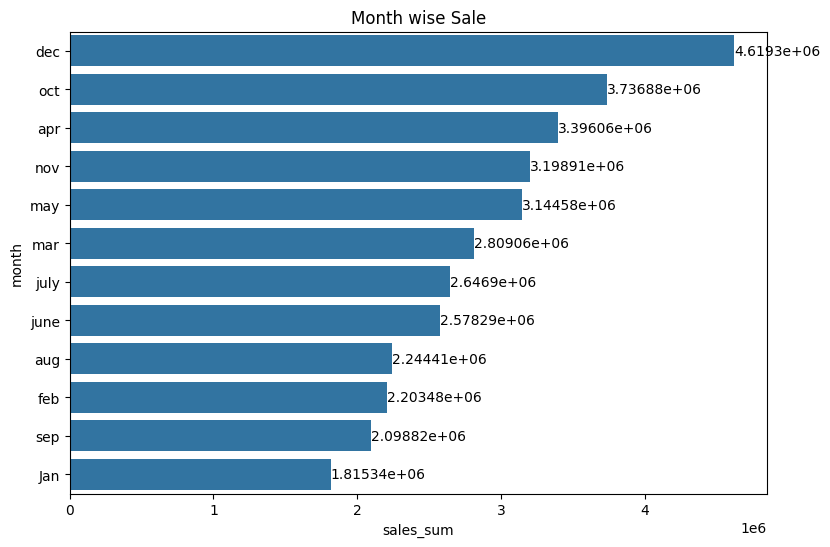

In [42]:
fig, ax = plt.subplots(figsize=(9, 6))

ax = sns.barplot(x = "sales_sum",
            y = "month",
            data = month_sales)

plt.title("Month wise Sale")

ax.bar_label(ax.containers[0])
plt.show()

In [43]:
def get_city(address):
    return address.split(",")[1].strip(" ")

def get_state(address):
    return address.split(",")[2].split(" ")[1]

df['city'] = df['purchase_address'].apply(lambda x: get_city(x) + ' (' + get_state(x) + ')')
df.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,month,sales,city
0,141234,iPhone,1,700.00,01/22/19 21:25,"944 Walnut St, Boston, MA 02215",Jan,700.00,Boston (MA)
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035",Jan,14.95,Portland (OR)
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016",Jan,23.98,San Francisco (CA)
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001",Jan,149.99,Los Angeles (CA)
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301",Jan,11.99,Austin (TX)


In [44]:
city_sales = df.groupby('city')['sales'].agg(city_sales = 'sum').sort_values(by="city_sales", ascending=False).reset_index()
city_sales

,city,city_sales
0,San Francisco (CA),8262203.91
1,Los Angeles (CA),5452570.80
2,New York City (NY),4664317.43
3,Boston (MA),3661642.01
4,Atlanta (GA),2795498.58
5,Dallas (TX),2767975.40
6,Seattle (WA),2747755.48
7,Portland (OR),1870732.34
8,Austin (TX),1819581.75
9,Portland (ME),449758.27


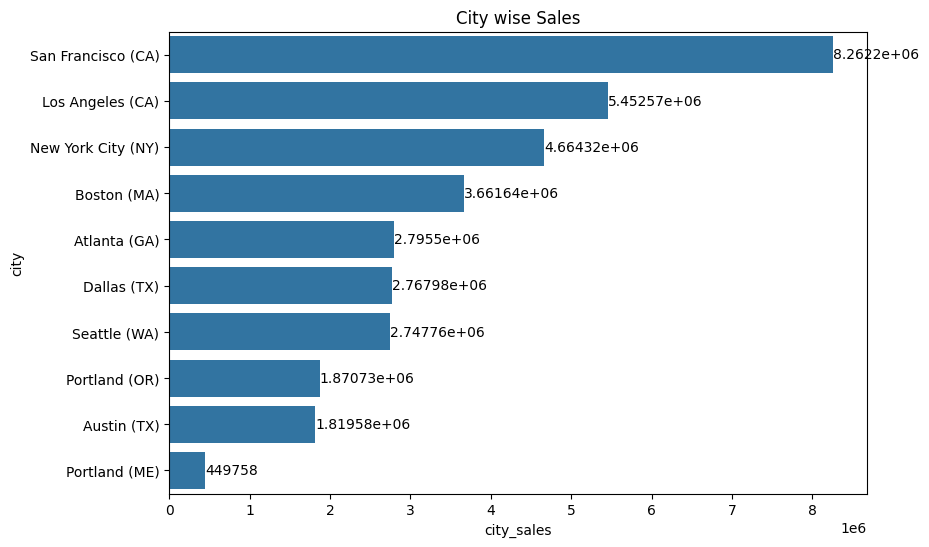

In [45]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(x = "city_sales",
            y = "city",
            data = city_sales)

plt.title("City wise Sales")
ax.bar_label(ax.containers[0])
plt.show()

In [46]:
df.nunique()

order_id            178437
product                 19
quantity_ordered         9
price_each              17
order_date          142395
purchase_address    140787
month                   12
sales                   54
city                    10
dtype: int64

In [47]:
df["product"].unique()

<StringArray>
[                    'iPhone',   'Lightning Charging Cable',
           'Wired Headphones',           '27in FHD Monitor',
     'AAA Batteries (4-pack)',     '27in 4K Gaming Monitor',
       'USB-C Charging Cable', 'Bose SoundSport Headphones',
   'Apple Airpods Headphones',         'Macbook Pro Laptop',
              'Flatscreen TV',            'Vareebadd Phone',
      'AA Batteries (4-pack)',               'Google Phone',
               '20in Monitor',     '34in Ultrawide Monitor',
            'ThinkPad Laptop',                   'LG Dryer',
         'LG Washing Machine']
Length: 19, dtype: str

In [48]:
product_sales = df.groupby('product')['quantity_ordered'].agg(quantity_ordered = 'sum').sort_values(by="quantity_ordered", ascending=False).reset_index()
product_sales

,product,quantity_ordered
0,AAA Batteries (4-pack),31017
1,AA Batteries (4-pack),27635
2,USB-C Charging Cable,23975
3,Lightning Charging Cable,23217
4,Wired Headphones,20557
5,Apple Airpods Headphones,15661
6,Bose SoundSport Headphones,13457
7,27in FHD Monitor,7550
8,iPhone,6849
9,27in 4K Gaming Monitor,6244


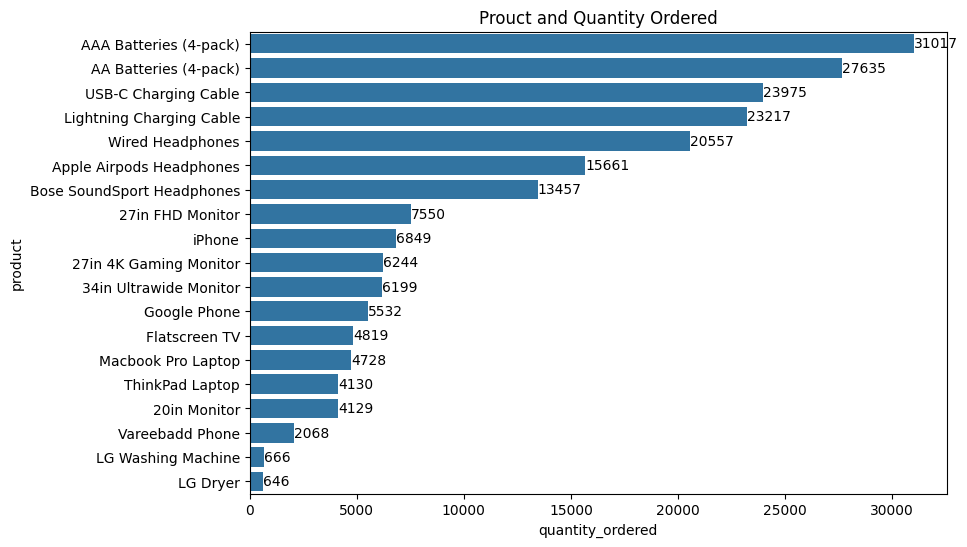

In [49]:
fig, ax = plt.subplots(figsize=(9, 6))

ax = sns.barplot(x = "quantity_ordered",
            y = "product",
            data = product_sales)

plt.title("Prouct and Quantity Ordered")

ax.bar_label(ax.containers[0])
plt.show()

In [50]:
time_sales = df
list_time = []
for i in time_sales['order_date']:
    list_time.append(i.split(" ")[1])
    
time_sales['time'] = list_time
time_sales.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,month,sales,city,time
0,141234,iPhone,1,700.00,01/22/19 21:25,"944 Walnut St, Boston, MA 02215",Jan,700.00,Boston (MA),21:25
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035",Jan,14.95,Portland (OR),14:15
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016",Jan,23.98,San Francisco (CA),13:33
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001",Jan,149.99,Los Angeles (CA),20:33
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301",Jan,11.99,Austin (TX),11:59


In [51]:
time_sales = df.groupby('time')['sales'].agg(time_sales = 'sum').sort_values(by="time_sales", ascending=False).reset_index()
time_sales.head()

,time,time_sales
0,19:01,54503.14
1,12:21,54181.96
2,19:16,54156.39
3,20:13,53149.51
4,19:20,52903.41


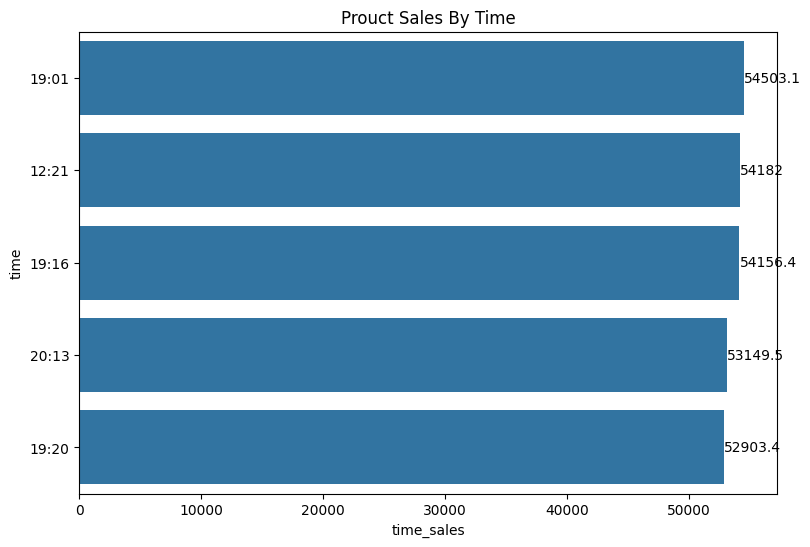

In [52]:
fig, ax = plt.subplots(figsize=(9, 6))

ax = sns.barplot(x = "time_sales",
            y = "time",
            data = time_sales.head())

plt.title("Prouct Sales By Time")

ax.bar_label(ax.containers[0])
plt.show()